# INEP - Média de alunos por turma

Média de Alunos por Turma na Educação Básica - Ensino Infantil, Ensino Fundamental e Médio, por Localização e Dependência Administrativa - Brasil, Regiões Geográficas e Unidades da Federação - 2024


# Carregando Conjunto de dados

In [58]:
import pandas as pd
 
atu = pd.read_excel('datasets/ATU_BRASIL_REGIOES_UFS_2024.xlsx', skiprows=8)
atu

,NU_ANO_CENSO,UNIDGEO,NO_CATEGORIA,NO_DEPENDENCIA,ED_INF_CAT_0,CRE_CAT_0,PRE_CAT_0,FUN_CAT_0,FUN_AI_CAT_0,FUN_AF_CAT_0,...,FUN_07_CAT_0,FUN_08_CAT_0,FUN_09_CAT_0,MULT_ETA_CAT_0,MED_CAT_0,MED_01_CAT_0,MED_02_CAT_0,MED_03_CAT_0,MED_04_CAT_0,MED_NS_CAT_0
0,2024,Brasil,Total,Total,15.4,13.7,17.3,22.4,20.9,25.9,...,26.1,26,25.9,13.9,28.9,30.6,28.8,27.5,21.3,21.8
1,2024,Brasil,Urbana,Total,15.6,13.6,17.7,23.8,21.7,27.1,...,27.2,27.2,27.3,16.4,29.6,31.2,29.4,28.2,21.4,23.6
2,2024,Brasil,Rural,Total,14.3,14,14.5,16,15.9,18.5,...,18.9,18.3,17.8,13.6,21,22.8,21.2,19.3,19.9,14.2
3,2024,Brasil,Total,Federal,12.3,10,14.6,26,22.1,28,...,28.2,28.8,27.8,--,30.5,34.3,31,28.1,23.3,27.6
4,2024,Brasil,Urbana,Federal,12.6,10.3,14.7,26,22.1,28,...,28.2,28.8,27.8,--,30.6,34.5,31.2,28.1,23,27.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
586,2024,Distrito Federal,Urbana,Pública,19,14.3,19,23.1,20.6,27.4,...,28,27.2,28.5,18,28.8,28.4,29,29.1,--,2
587,2024,Distrito Federal,Rural,Pública,16.3,9.9,16.7,19.9,18.8,22.5,...,23.7,21.3,22.8,20,22.3,22.7,22.6,21.5,--,--
588,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
589,Fonte: Censo da Educação Básica 2024/INEP.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Preparando dados para análise

**Obs.:** Todas as colunas estão sendo identificadas como Object
 
Antes de resolver esse problemas vamos selecionar as colunas Unidade Geográfica, Localização, Dependência Administrativa, Total Infantil, Total Fundamental e Total Médio para efetuar a análise

In [16]:
atu = atu.iloc[:, [1,2,3,4,7,20]]
atu

,UNIDGEO,NO_CATEGORIA,NO_DEPENDENCIA,ED_INF_CAT_0,FUN_CAT_0,MED_CAT_0
0,Brasil,Total,Total,15.4,22.4,28.9
1,Brasil,Urbana,Total,15.6,23.8,29.6
2,Brasil,Rural,Total,14.3,16,21
3,Brasil,Total,Federal,12.3,26,30.5
4,Brasil,Urbana,Federal,12.6,26,30.6
...,...,...,...,...,...,...
586,Distrito Federal,Urbana,Pública,19,23.1,28.8
587,Distrito Federal,Rural,Pública,16.3,19.9,22.3
588,NaN,NaN,NaN,NaN,NaN,NaN
589,NaN,NaN,NaN,NaN,NaN,NaN


Dicionário:
- ug: Unidade Geográfica
- loc: Localização
- da: Dependência Administrativa
- ti: Total Ensino Infantil
- tf: Total Ensino Fundamental
- tm: Total Ensino Médio

In [20]:
colunas = ["UG", "LOC", "DA", "TI", "TF", "TM"]
atu.columns = colunas
atu

,UG,LOC,DA,TI,TF,TM
0,Brasil,Total,Total,15.4,22.4,28.9
1,Brasil,Urbana,Total,15.6,23.8,29.6
2,Brasil,Rural,Total,14.3,16,21
3,Brasil,Total,Federal,12.3,26,30.5
4,Brasil,Urbana,Federal,12.6,26,30.6
...,...,...,...,...,...,...
586,Distrito Federal,Urbana,Pública,19,23.1,28.8
587,Distrito Federal,Rural,Pública,16.3,19.9,22.3
588,NaN,NaN,NaN,NaN,NaN,NaN
589,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
atu.info

<bound method DataFrame.info of                    UG     LOC       DA    TI    TF    TM
0              Brasil   Total    Total  15.4  22.4  28.9
1              Brasil  Urbana    Total  15.6  23.8  29.6
2              Brasil   Rural    Total  14.3    16    21
3              Brasil   Total  Federal  12.3    26  30.5
4              Brasil  Urbana  Federal  12.6    26  30.6
..                ...     ...      ...   ...   ...   ...
586  Distrito Federal  Urbana  Pública    19  23.1  28.8
587  Distrito Federal   Rural  Pública  16.3  19.9  22.3
588               NaN     NaN      NaN   NaN   NaN   NaN
589               NaN     NaN      NaN   NaN   NaN   NaN
590               NaN     NaN      NaN   NaN   NaN   NaN

[591 rows x 6 columns]>

Vamos considerar que os valores ausentes indicam que não existem escolas com aquela categoria de ensino na região. 

In [48]:
df = atu.replace('--', 0)

C:\Users\GTX1050\AppData\Local\Temp\ipykernel_17300\3170459046.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = atu.replace('--', 0)


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 591 entries, 0 to 590
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   UG      588 non-null    object 
 1   LOC     588 non-null    object 
 2   DA      588 non-null    object 
 3   TI      588 non-null    float64
 4   TF      588 non-null    float64
 5   TM      588 non-null    float64
dtypes: float64(3), object(3)
memory usage: 27.8+ KB


In [54]:
df.groupby("UG")[["TI","TF", "TM"]].median().round(2)

,TI,TF,TM
UG,,,
Acre,14.20,20.80,22.40
Alagoas,16.70,20.00,33.10
Amapá,12.90,17.40,27.20
Amazonas,12.90,21.20,26.50
Bahia,13.95,20.95,27.90
Brasil,14.35,22.40,28.45
Ceará,14.95,20.10,31.30
Centro-Oeste,15.30,23.50,27.75
Distrito Federal,16.30,22.30,28.90


In [53]:
df.groupby("LOC")[["TI","TF", "TM"]].median()

,TI,TF,TM
LOC,,,
Rural,12.45,15.1,22.0
Total,15.30,22.2,27.9
Urbana,15.80,24.4,28.7


In [55]:
df.groupby(["UG", "LOC"])[["TI","TF", "TM"]].median()

TI     TF     TM
UG        LOC                        
Acre      Rural    9.90  13.90  11.70
          Total   16.85  20.50  22.25
          Urbana  20.90  25.35  32.60
Alagoas   Rural   16.60  19.80  33.10
          Total   15.35  23.85  32.45
...                 ...    ...    ...
São Paulo Total   14.30  25.85  31.00
          Urbana  15.45  25.95  31.15
Tocantins Rural   12.00  12.40  14.70
          Total   15.95  21.35  24.95
          Urbana  16.35  23.80  26.75

[99 rows x 3 columns]

In [57]:
pd.pivot_table(df, values="TF", index="UG", columns="DA", aggfunc="median")

DA,Estadual,Federal,Municipal,Privada,Pública,Total
UG,,,,,,
Acre,21.2,25.0,18.7,20.8,20.2,20.2
Alagoas,29.6,0.0,24.5,17.5,25.0,23.2
Amapá,21.5,0.0,20.1,17.1,20.9,20.5
Amazonas,28.3,29.5,20.3,17.6,22.2,21.8
Bahia,28.5,26.2,21.3,17.2,21.6,20.6
Brasil,26.1,26.0,22.4,19.0,23.3,22.4
Ceará,17.7,28.9,23.6,18.1,23.5,22.1
Centro-Oeste,26.0,30.3,23.6,19.0,24.6,23.4
Distrito Federal,22.9,31.5,NaN,20.6,22.9,22.2


## Visualização dos dados

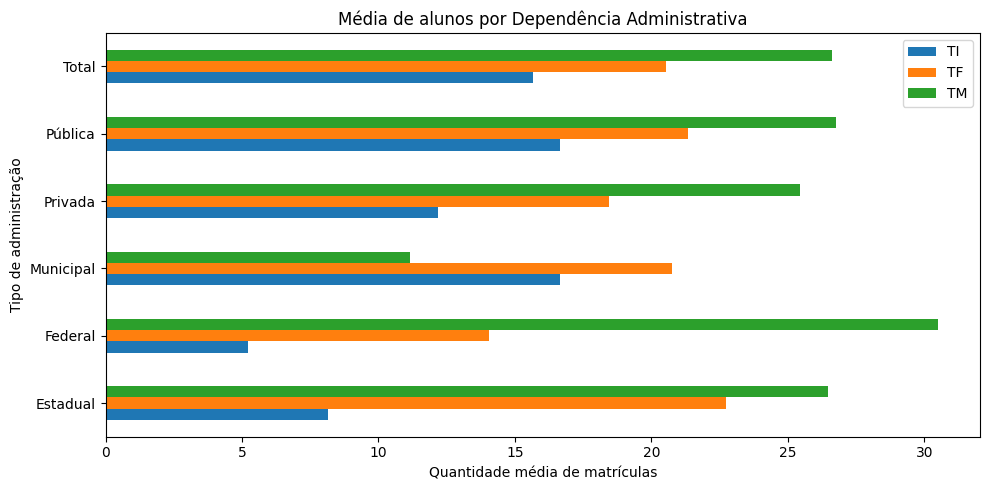

In [60]:
import matplotlib.pyplot as plt
 
df.groupby("DA")[["TI", "TF", "TM"]].mean().plot(kind="barh", figsize=(10, 5))
plt.title("Média de alunos por Dependência Administrativa")
plt.xlabel("Quantidade média de matrículas")
plt.ylabel("Tipo de administração")
plt.tight_layout()
plt.show()

(array([0, 1, 2]),
 [Text(0, 0, 'Rural'), Text(1, 0, 'Total'), Text(2, 0, 'Urbana')])

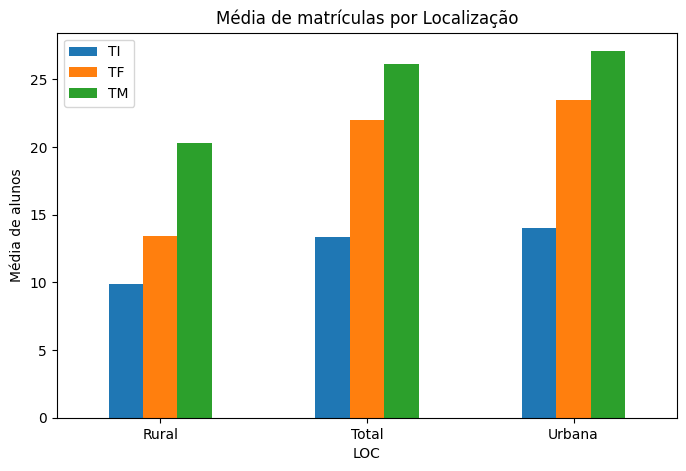

In [62]:
df.groupby("LOC")[["TI", "TF", "TM"]].mean().plot(kind="bar", figsize=(8, 5))
plt.title("Média de matrículas por Localização")
plt.ylabel("Média de alunos")
plt.xticks(rotation=0)

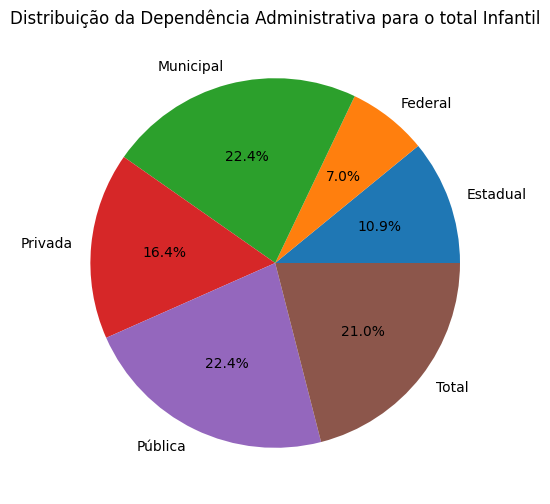

In [63]:
df.groupby("DA")["TI"].mean().plot.pie(autopct="%.1f%%", figsize=(6, 6), ylabel="")
plt.title("Distribuição da Dependência Administrativa para o total Infantil")
plt.show()


In [66]:
df.to_csv("atu-mod.csv", sep=';', decimal=',')